# TileStats: Hextile and Tile Binning

Anton Antonov   
February 2026

---

## Introduction

This notebook demonstrates the usage of the functions `hextile_bins`, `hextile_histogram`, `tile_bins`, and `tile_histogram` provided by the Python package ["TileStats"](https://pypi.org/project/TileStats/), [AAp1]. Randomly generated 2D points and corresponding visualizations are used.

----

## Setup

In this package relevant packages are loaded and plot parameters are setup.

In [50]:
import math
import os
import random
import sys

import pandas as pd
from DataTypeSystem import *

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl


# Make the local package importable without installation
#sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

from TileStats import (
    hextile_bins,
    hextile_histogram,
    tile_bins,
    tile_histogram,
)

Plot styling variables:

In [51]:
points_color = '#2b6cb0'
hextile_cmap = 'Grays'
tile_cmap = 'Greens'
plot_bg = '#1f1f1f'
figure_bg = '#1f1f1f'

mpl.rcParams.update({
    "axes.edgecolor": "silver",
    "axes.labelcolor": "silver",
    "xtick.color": "silver",
    "ytick.color": "silver",
    "text.color": "silver",
})

Special color functions:

In [52]:
black_blue = LinearSegmentedColormap.from_list(
    "black_blue",
    ["#2F2F2F", "#0000ff"]
)

This makes the library "matplotlib" to output SVG images (makes it easier to export the notebook to Markdown):

In [53]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

-----

## Random points

Generate random 2D data points:

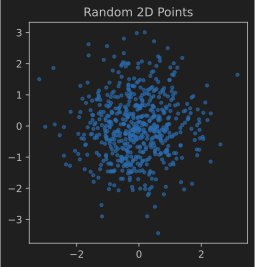

In [54]:
random.seed(7322)
n_points = 600
data = [(random.gauss(0, 1.0), random.gauss(0, 1.0)) for _ in range(n_points)]

xs = [p[0] for p in data]
ys = [p[1] for p in data]

plt.figure(figsize=(5, 4))
plt.scatter(xs, ys, s=10, alpha=0.6, color=points_color)
plt.title('Random 2D Points')
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
ax.set_facecolor(plot_bg)
ax.figure.set_facecolor(figure_bg)
#plt.show()

----

## Hextile bins

Hextile bins (center keys):

In [55]:
hextile_bins = hextile_bins(data, bin_size=0.6, polygon_keys=False)

Show a few bin centers and counts:

In [56]:
list(hextile_bins.items())[:8]

[((0.6, -1.0392304845413263), 12),
 ((1.2, -1.0392304845413263), 10),
 ((0.6, 0.0), 31),
 ((0.0, 0.0), 33),
 ((-0.6, 0.0), 21),
 ((-1.2, 1.0392304845413263), 10),
 ((-1.2, 0.0), 20),
 ((-0.8999999999999999, -1.5588457268119895), 8)]

Hextile histogram (colored polygons):

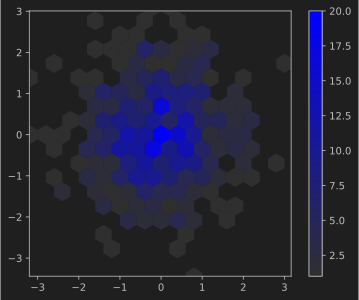

In [57]:
hex_hist = hextile_histogram(
    data,
    bin_size=0.4,
    histogram_type='ColoredPolygons',
    plot=True,
    plot_legends='Automatic',
    color_function=black_blue, #hextile_cmap,
    facecolor=plot_bg,
)
hex_hist['figure'].set_facecolor(plot_bg)
#fig = hex_hist['figure']

----

## Tile bins

Rectangular tile bins (center keys):

In [58]:
tile_bins = tile_bins(data, bin_size=0.8, polygon_keys=False)

Show a few bins centers and counts:

In [59]:
list(tile_bins.items())[:8]

[((0.4, -1.2000000000000002), 26),
 ((1.2000000000000002, -1.2000000000000002), 13),
 ((1.2000000000000002, 0.4), 22),
 ((0.4, 0.4), 43),
 ((-0.4, -0.4), 57),
 ((-1.2000000000000002, 1.2000000000000002), 14),
 ((-1.2000000000000002, 0.4), 33),
 ((-1.2000000000000002, -1.2000000000000002), 19)]

Tile histogram (colored polygons):

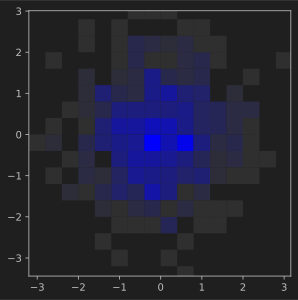

In [60]:
tile_hist = tile_histogram(
    data,
    bin_size=0.4,
    histogram_type='ColoredPolygons',
    plot=True,
    color_function= black_blue, #tile_cmap,
    facecolor=plot_bg,
)
tile_hist['figure'].set_facecolor(plot_bg)
#fig = tile_hist['figure']

-----

## Mapping USA counties populations

Using the function `hextile_histogram` in this section we visualize USA county populations over a hexagonal grid with cell radius 2 degrees (≈ 140 miles, ≈222 kilometers.)
Here we read the populations data:

In [ ]:
url = 'https://raw.githubusercontent.com/antononcube/SystemModeling/refs/heads/master/Data/dfUSACountyRecords.csv'
df = pd.read_csv(url)

Filter the geo-spatial data to be within certain boundaries and show its structure:

In [62]:
populations = {(lon, lat): pop for lat, lon, pop in zip(df["Lat"], df["Lon"], df["Population"]) if lon > -135 and 20 <= lat and lat <= 55}
deduce_type(populations)


Assoc(Pair(Atom(<class 'float'>), Atom(<class 'float'>)), Atom(<class 'int'>), 3109)

Make the geo-spatial histogram (that consists of hexagons):

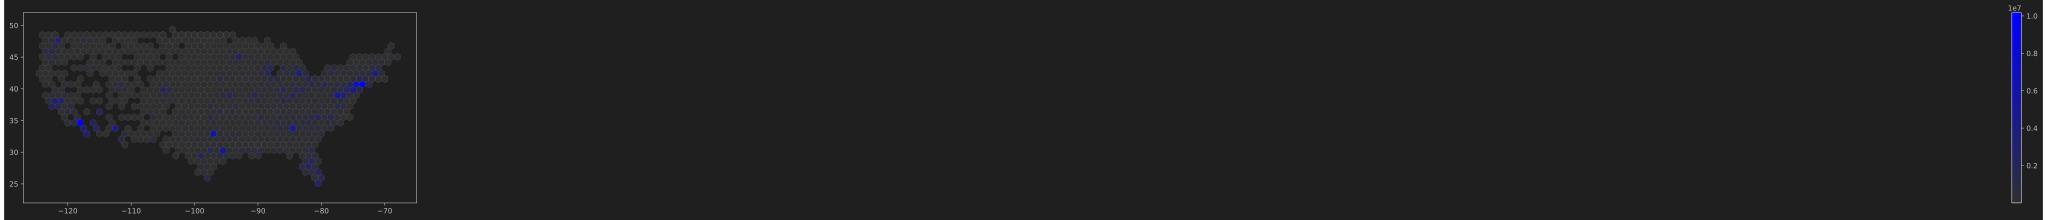

In [67]:
args_dict = {
    "bin_size": 1,
    "data_range": ((-127, -65), (22, 52)),
    "histogram_type": "ColoredPolygons",
    "overlap_factor": 1,
    "edge_color": "DimGray",
    "line_width": 0.2,
    "plot": True,
    "plot_legends": "Automatic",
    "color_function": black_blue,  # hextile_cmap,
    "facecolor": plot_bg
}

geo_hist = hextile_histogram(populations, **args_dict)
geo_hist['figure'].set_facecolor(plot_bg)
geo_hist['figure'].set_figwidth(800)

Here is the corresponding square tile histogram:

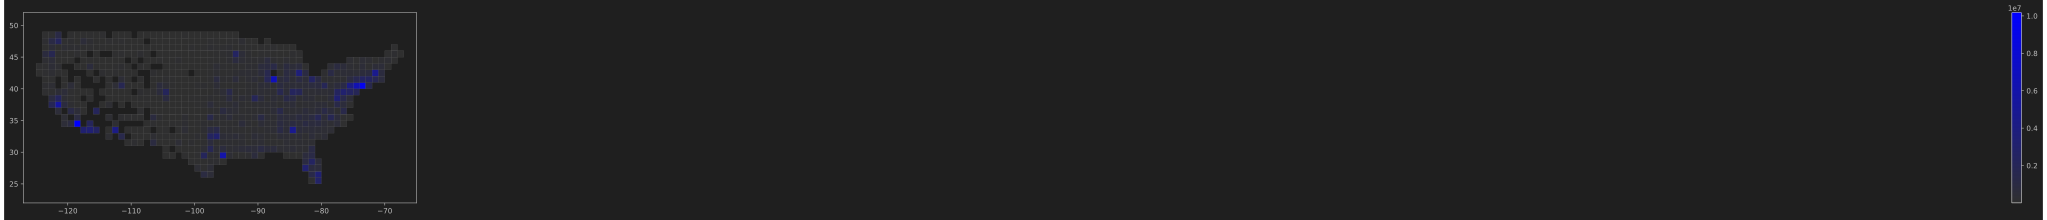

In [68]:
geo_hist = tile_histogram(populations, **args_dict)
geo_hist['figure'].set_facecolor(plot_bg)
geo_hist['figure'].set_figwidth(800)

----

## References

### Articles, blog posts

[AA1] Anton Antonov, ["A monad for Epidemiologic Compartmental Modeling Workflows"](https://mathematicaforprediction.wordpress.com/2021/01/02/epidemiology-compartmental-modeling-monad/), (2021), [MathematicaForPrediction at WordPress](https://mathematicaforprediction.wordpress.com).

### Packages 

[AAp1] Anton Antonov, [TileStats, Python package](https://pypi.org/project/TileStats), (2026), [PyPI.org](https://pypi.org).

[AAp2] Anton Antonov, [TileStats, Wolfram Language paclet](https://resources.wolframcloud.com/PacletRepository/resources/AntonAntonov/TileStats/), (2023), [Wolfram Language Paclet Repository](https://resources.wolframcloud.com/PacletRepository).

[AAp3] Anton Antonov, [TileStats, Java package](https://github.com/antononcube/Java-TileStats), (2023), [GitHub/antononcube](https://github.com/antononcube).